In [2]:
import sys
sys.path.insert(0, "cobra/src")           # so Python can find the cobra package
from cobra import load_detector_from_yaml

detector = load_detector_from_yaml("/lustre/LHCb/carlos.arenas/cobra/config/codex-beta.yaml")

/lustre/LHCb/carlos.arenas/cobra/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
for module in detector.modules.values():
    print(module.id, module.name, module.position)     # position in metres, LHCb reference frame

0 GF [0.10951 0.      2.10598]
1 FL [0.      0.06523 0.096  ]
2 CR [1.24305 0.06523 2.1661 ]
3 FR [0.07303 0.06523 2.1661 ]
4 CL [1.17002 0.06523 0.096  ]
5 RF [0.10993 0.0647  2.278  ]
6 BL [2.4069  1.98822 0.096  ]
7 RB [1.27833 1.98875 2.20498]
8 SF [0.10951 2.10578 2.10598]
9 BR [2.33387 1.98822 2.1661 ]
10 LF [0.10993 1.98875 0.     ]
11 SB [2.30469 2.03275 2.10598]
12 GB [ 2.30469 -0.07303  2.10598]
13 LB [2.30703 1.98875 0.07303]


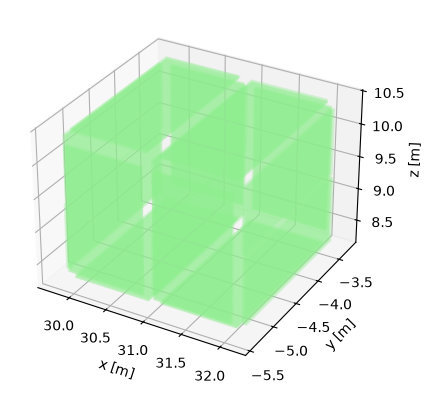

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from cobra.geometry import transform_surface

# transform_surface gives you the 8 corners of one singlet, already placed in 3D space
faces = [[0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4], [1, 2, 6, 5], [2, 3, 7, 6], [3, 0, 4, 7]]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
for module in detector.modules.values():
    for singlet_id in module.singlet_ids:
        singlet = detector.singlets[singlet_id]
        corners = transform_surface(detector, module, singlet)
        ax.add_collection3d(Poly3DCollection([corners[f] for f in faces], alpha=0.2, facecolor="lightgreen"))
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
plt.savefig("images/detector.png")

In [5]:
import pyhepmc

path = "/lustre/LHCb/carlos.arenas/data/v009_pmu7-fn0k-fc0-ww3_inelastic_none_1_1e4.hepmc"
with pyhepmc.open(path) as f:
    next(iter(f))
    event = next(iter(f))          # just the first event; loop over f to go through all of them

In [6]:
for key, value in event.attributes.items():
    if key.startswith("RawBank_"):
        module, strip, time0, time1 = [int(x) for x in str(value).split()]
        print(module, strip, time0, time1)

1 97 0 9
1 139 0 6
7 139 0 12
2 135 8 9
1 134 0 5
7 140 0 12
2 47 0 8
7 52 0 12
1 44 0 6
2 45 0 8
9 31 0 12
3 49 7 0
1 143 6 0
7 53 0 12
1 47 6 0
9 30 0 12
9 110 12 0
9 111 12 0
9 126 0 12
3 138 0 6
3 41 0 7
2 40 8 0
1 36 0 4
1 142 6 0
7 42 0 12
3 38 0 7
2 88 0 8
7 90 12 0
1 84 4 0
3 86 7 0
3 6 0 7
9 12 12 0
9 108 12 0
9 60 0 12
1 43 0 6
2 94 8 0
1 93 6 0
2 95 9 0
7 100 12 0
1 94 6 6
8 86 0 8
3 81 7 0
3 82 7 0
1 81 0 5
3 83 7 0
5 94 0 10
3 55 7 0
3 56 7 0
2 56 9 0
9 63 0 12
3 57 7 0
3 58 7 0
2 38 0 9
1 37 0 5
7 43 0 12
3 39 0 7
1 138 0 6
2 39 8 9
3 40 0 7
3 4 0 7
9 13 12 0
3 7 0 7
3 137 0 6
3 100 0 6
2 86 9 8
3 87 7 0
5 142 10 0
5 46 10 0
1 77 0 5
2 46 9 0
1 1 0 9
1 125 4 0
11 80 10 0
8 134 8 0
1 28 0 9
8 35 0 8
1 49 6 0
2 50 9 0
8 38 8 0
1 31 5 0
9 15 12 0
1 50 9 0
10 125 10 0
11 126 0 11
11 125 0 11
1 124 0 9
8 131 0 8
1 92 6 0
2 93 8 9
10 30 10 0
5 25 0 10
11 31 0 10
10 77 0 10
1 48 6 0
2 49 9 0
5 24 0 10
11 30 0 10
1 29 4 0
8 36 0 8
9 79 12 0
11 81 10 0
1 132 0 5
11 72 0 11
10 132 

In [7]:
import numpy as np
from cobra import StripDecoder

rows = []
for key, value in event.attributes.items():
    if key.startswith("RawBank_"):
        module, strip, time0, time1 = [int(x) for x in str(value).split()]
        rows.append([0, module, strip, time0, time1])           # 0 = sourceID placeholder

raw_banks = np.array(rows, dtype=np.int16)
strips = StripDecoder()._process(raw_banks)

In [8]:
for module, singlet, strip_index, time, kind in strips:
    print(module, singlet, time, kind)

1 2 9 0
1 2 6 1
7 2 12 1
2 2 9 1
1 2 5 1
7 2 12 1
2 1 8 1
7 2 12 0
1 1 6 1
2 1 8 1
9 1 12 1
7 2 12 0
9 1 12 1
9 2 12 1
3 2 6 1
3 1 7 1
1 1 4 1
7 1 12 1
3 1 7 1
2 2 8 0
3 1 7 0
9 2 12 0
1 1 6 1
1 2 6 0
8 2 8 0
1 2 5 0
5 2 10 0
9 2 12 0
2 1 9 1
1 1 5 1
7 1 12 1
3 1 7 1
1 2 6 1
2 1 9 1
3 1 7 1
3 1 7 0
3 1 7 0
3 2 6 1
3 2 6 0
2 2 8 0
1 2 5 0
1 1 9 0
1 1 9 1
8 1 8 1
11 2 11 1
11 2 11 1
1 2 9 1
8 2 8 1
2 2 9 0
5 1 10 1
11 1 10 1
10 2 10 0
5 1 10 1
11 1 10 1
8 1 8 1
1 2 5 1
11 2 11 0
10 2 10 1
2 1 9 1
1 2 5 1
3 1 7 0
5 2 10 1
11 2 11 1
2 1 9 1
1 1 9 1
1 2 5 0
2 2 8 0
1 2 5 0
10 1 10 1
1 1 9 0
2 1 9 0
3 1 7 1
1 2 9 0
3 2 6 0
2 2 9 0
10 2 10 0
2 2 9 1
2 1 8 0
3 1 7 0
3 2 6 1
2 2 8 1
9 2 12 1
3 2 6 1
3 1 7 0
3 2 6 1
2 2 8 1
1 1 4 1
3 1 7 1
7 1 12 1
1 2 6 0
3 2 7 0
1 2 5 1
2 1 8 0
3 0 7 0
1 1 6 0
1 0 6 0
9 1 12 0
9 1 12 0
2 0 8 0
1 1 6 0
7 0 12 1
1 0 4 1
3 0 7 1
9 0 12 0
9 1 12 0
2 0 8 1
1 0 6 1
2 0 9 1
7 1 12 0
1 0 6 1
3 0 7 1
3 0 7 1
3 0 7 1
3 0 7 0
3 0 7 0
2 0 9 0
3 0 7 0
3 0 7 0
2 0 8 0
9 0 1

In [9]:
from cobra.geometry import strip_to_global_position

module = detector.modules[9]                          # pick a module id, e.g. from your printed strips
singlet = detector.singlets[module.singlet_ids[1]]     # singlet 1 (the middle one) of that module
x, y, z = strip_to_global_position(detector, module, singlet, eta_strip=30, phi_strip=43)

print(x, y, z)

32.103865 -4.68322625 9.379594999999998


In [10]:
def strip_points(detector, strips):
    points = []
    for module_id in {int(r[0]) for r in strips}:      # go module by module...
        module = detector.modules[module_id]
        for slot in range(3):                           # ...and singlet by singlet within the module
            here = [r for r in strips if int(r[0]) == module_id and int(r[1]) == slot]
            phi_strips = [int(r[2]) for r in here if int(r[4]) == 0]
            eta_strips = [int(r[2]) for r in here if int(r[4]) == 1]
            singlet = detector.singlets[module.singlet_ids[slot]]
            for phi in phi_strips:
                for eta in eta_strips:
                    point = strip_to_global_position(detector, module, singlet, eta_strip=eta, phi_strip=phi)
                    points.append(point)
    return np.array(points)

points = strip_points(detector, strips.tolist())

print(points)

[[29.750945   -3.87065375  8.941245  ]
 [29.750945   -3.87065375  9.222495  ]
 [29.750945   -3.87065375  9.253745  ]
 ...
 [31.578985   -3.277665    9.55725625]
 [31.610235   -3.277665    9.55725625]
 [31.547735   -3.277665    9.55725625]]


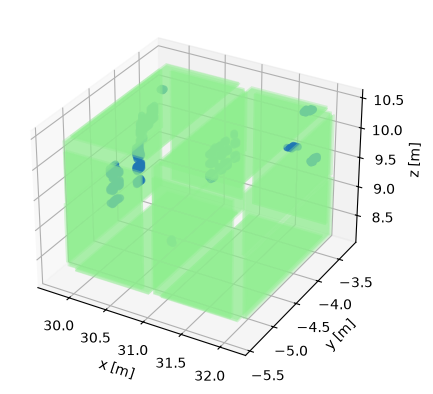

In [26]:
import matplotlib.pyplot as plt
import numpy as np


# fig = plt.figure(figsize=(9, 7))
# ax = fig.add_subplot(111, projection="3d")

faces = [[0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4], [1, 2, 6, 5], [2, 3, 7, 6], [3, 0, 4, 7]]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
for module in detector.modules.values():
    for singlet_id in module.singlet_ids:
        singlet = detector.singlets[singlet_id]
        corners = transform_surface(detector, module, singlet)
        ax.add_collection3d(Poly3DCollection([corners[f] for f in faces], alpha=0.2, facecolor="lightgreen"))
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")


points = np.array(points)
x = points[:,0]
y = points[:,1]
z = points[:,2]

ax.scatter(x,y,z)

plt.savefig("images/detector.png")

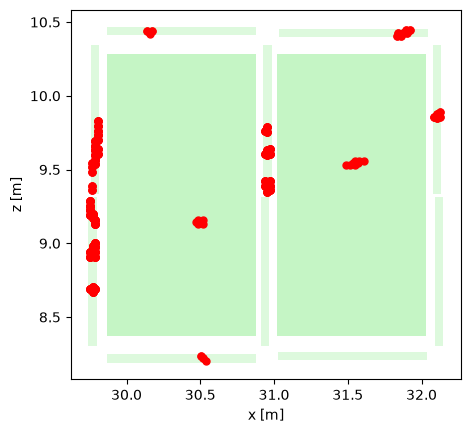

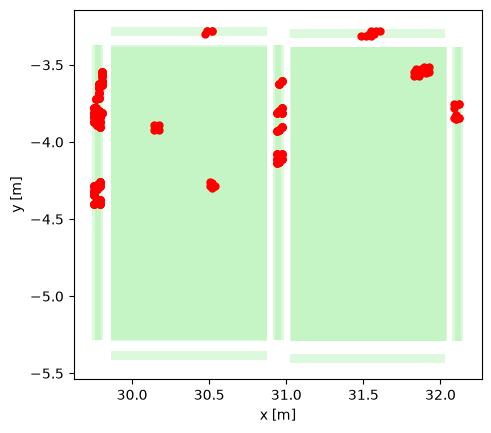

In [ ]:
fig, ax = plt.subplots()
for module in detector.modules.values():
    corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
    lo, hi = corners.min(axis=0), corners.max(axis=0)
    ax.add_patch(plt.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2], facecolor="lightgreen", alpha=0.3))
ax.scatter(points[:, 0], points[:, 2], c="r", s=25)          # x, z: a view from above
ax.set_xlabel("x [m]"); ax.set_ylabel("z [m]"); ax.set_aspect("equal")
plt.savefig("event_alzado.png")

fig, ax = plt.subplots()
for module in detector.modules.values():
    corners = np.vstack([transform_surface(detector, module, detector.singlets[s]) for s in module.singlet_ids])
    lo, hi = corners.min(axis=0), corners.max(axis=0)
    ax.add_patch(plt.Rectangle((lo[0], lo[1]), hi[0] - lo[0], hi[1] - lo[1], facecolor="lightgreen", alpha=0.3))
ax.scatter(points[:, 0], points[:, 1], c="r", s=25)          # x, z: a view from above
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_aspect("equal")
plt.savefig("event_planta.png")